# G-LiHT integrated instruments — swath & constraint comparison

NASA Goddard's **G-LiHT** (Goddard's LiDAR, Hyperspectral & Thermal)
is a multi-instrument airborne payload flown on a **Beechcraft King
Air A90** at a **nominal altitude of 335 m AGL** and a **nominal
velocity of 110–150 kt (~57–77 m/s)** (G-LiHT AK 2022 SW66 campaign
metadata, Dynamic Aviation N80Y).  Its value is the co-registered
multi-instrument view of the same ground.  HyPlan ships every G-LiHT
sensor as a reference instance.

This notebook uses HyPlan's calibrated **`KingAirA90`** as a
reference host speed; the speed-vs-altitude plots also overlay
G-LiHT's documented 110–150 kt operational survey envelope so the
binding constraints can be read against both the modelled cruise
and the published operational range.

**Scope.**  Five instruments per the 2022 G-LiHT payload:

- **VNIR** pushbroom (Headwall Microhyperspec E Series, 75 Hz)
- **SWIR** pushbroom (Headwall Microhyperspec SWIR, 75 Hz) — new in
  the 2022+ G-LiHT generation
- **Thermal** frame camera (Xenics Gobi-640 GigE Vision, 50 Hz)
- **Dual Riegl VQ-480i** lidar rig (300 kHz PRF, 150 Hz scan rate)
- **HRAC** frame camera (Phase One iXM-RS100F-RS, 1 Hz)

**Key questions, answered live below.**

1. At G-LiHT's nominal 335 m AGL, which instrument sets the maximum
   ground speed?
2. Which instrument caps the maximum altitude?
3. How do those answers change with altitude?

All numbers come from the live HyPlan reference instances; the
sensor-physics caveats (motion blur during integration, sensor
linearity, etc.) are flagged where relevant but not modelled
geometrically.

Authoritative specs source: NASA GSFC's **G-LiHT AK 2022 SW66
campaign metadata** (PDF at glihtdata.gsfc.nasa.gov), with the
Loudon June 2017 metadata as a confirming/historical reference.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hyplan import ureg
from hyplan.aircraft import KingAirA90
from hyplan.flight_line import FlightLine
from hyplan.instruments import (
    GLIHT_DUAL_VQ_480I,
    GLIHT_HRAC,
    GLIHT_THERMAL,
    GLiHT_SWIR,
    GLiHT_VNIR,
)
from hyplan.swath import generate_swath_polygon


def _show(fig=None):
    if fig is None:
        fig = plt.gcf()
    plt.show()
    plt.close(fig)


# Instantiate the line scanners; rig / cameras are shared singletons.
vnir = GLiHT_VNIR()
swir = GLiHT_SWIR()                       # new in the 2022+ G-LiHT payload
thermal = GLIHT_THERMAL                   # frame camera (Gobi-640), not a pushbroom
lidar_rig = GLIHT_DUAL_VQ_480I
lidar_unit = lidar_rig.units[0].lidar     # underlying single ALSLidar for MTA / per-unit diagnostics
hrac = GLIHT_HRAC

# Host aircraft: HyPlan's calibrated KingAirA90 as a reference host
# speed.  G-LiHT's documented 110–150 kt operational velocity envelope
# (AK 2022 SW66 campaign metadata, Dynamic Aviation N80Y) is overlaid
# on the speed-vs-altitude plots below.
aircraft = KingAirA90()
ALT_NOMINAL = 335 * ureg.meter            # G-LiHT's published nominal survey altitude

# G-LiHT survey velocity envelope, via pint to keep unit handling consistent.
SURVEY_LO = (110 * ureg.knot).to('meter / second').magnitude
SURVEY_HI = (150 * ureg.knot).to('meter / second').magnitude
CRUISE_MPS = float(aircraft.cruise_speed_at(ALT_NOMINAL).m_as('meter / second'))
print(f'G-LiHT operational velocity envelope: {SURVEY_LO:.1f}–{SURVEY_HI:.1f} m/s '
      f'(110–150 kt, per AK 2022 SW66 metadata)')
print(f'KingAirA90 calibrated cruise @ {ALT_NOMINAL:~}: {CRUISE_MPS:.1f} m/s '
      f'({float(aircraft.cruise_speed_at(ALT_NOMINAL).m_as("knot")):.0f} kt)')

LIDAR_TARGET_DENSITY = 10 * ureg('1/meter**2')
HRAC_OVERLAP_PCT = 80.0
THERMAL_OVERLAP_PCT = 80.0

G-LiHT operational velocity envelope: 56.6–77.2 m/s (110–150 kt, per AK 2022 SW66 metadata)
KingAirA90 calibrated cruise @ 335 m: 73.6 m/s (143 kt)


## 1. Instrument inventory

Pulled live from the reference instances so future spec edits stay in sync.

In [2]:
rows = []

for label, sensor in [
    ('VNIR (pushbroom)',    vnir),
    ('SWIR (pushbroom)',    swir),
]:
    rows.append({
        'Instrument': label,
        'Class': type(sensor).__name__,
        'FOV': f'{float(sensor.fov):.1f}°',
        'Frame rate': f'{float(sensor.frame_rate.m_as("hertz")):.1f} Hz',
        'Detector': f'{sensor.across_track_pixels} across-track pixels',
    })

rows.append({
    'Instrument': 'Thermal (Gobi-640 frame camera)',
    'Class': type(thermal).__name__,
    'FOV': f'{thermal.fov_x:.1f}° × {thermal.fov_y:.1f}°',
    'Frame rate': f'{float(thermal.frame_rate.m_as("hertz")):.1f} Hz',
    'Detector': f'{thermal.resolution_x} × {thermal.resolution_y} microbolometer',
})

rows.append({
    'Instrument': 'Dual VQ-480i (lidar rig)',
    'Class': type(lidar_rig).__name__,
    'FOV': f'±{float(lidar_unit.half_angle):.0f}° cross-track, ±7° pitch',
    'Frame rate': f'{float(lidar_unit.scan_rate.m_as("hertz")):.0f} Hz scan rate',
    'Detector': '2 × single-beam laser, 300 kHz PRF each (combined density)',
})

rows.append({
    'Instrument': 'HRAC (Phase One iXM-RS100F-RS)',
    'Class': type(hrac).__name__,
    'FOV': f'{hrac.fov_x:.1f}° × {hrac.fov_y:.1f}°',
    'Frame rate': f'{float(hrac.frame_rate.m_as("hertz")):.1f} Hz',
    'Detector': f'{hrac.resolution_x:,} × {hrac.resolution_y:,} CMOS',
})

pd.DataFrame(rows)

,Instrument,Class,FOV,Frame rate,Detector
0,VNIR (pushbroom),GLiHT_VNIR,55.3°,75.0 Hz,645 across-track pixels
1,SWIR (pushbroom),GLiHT_SWIR,20.9°,75.0 Hz,192 across-track pixels
2,Thermal (Gobi-640 frame camera),FrameCamera,41.8° × 32.0°,50.0 Hz,640 × 480 microbolometer
3,Dual VQ-480i (lidar rig),MultiALSLidarRig,"±30° cross-track, ±7° pitch",150 Hz scan rate,"2 × single-beam laser, 300 kHz PRF each (combi..."
4,HRAC (Phase One iXM-RS100F-RS),FrameCamera,56.2° × 43.6°,1.0 Hz,"11,608 × 8,708 CMOS"


## 2. Swath / footprint comparison at 335 m AGL

Synthetic 2 km north-going flight line at the KingAirA90 cruise
speed (~74 m/s).  VNIR, SWIR, and the lidar rig produce continuous
swath polygons; thermal and HRAC are frame cameras, so this panel
shows **consecutive frames at the operational trigger spacing**
(`ground_speed × frame_period`) so the per-frame overlap is visible.

The overlap pattern depends entirely on the frame rate:

- **HRAC** at 1 Hz × 74 m/s → 74 m between frame centres, 268 m
  along-track footprint → frames overlap by ~72%.  Visible as
  distinct rectangles with broad shared regions.
- **Thermal Gobi-640** at 50 Hz × 74 m/s → **1.47 m** between frame
  centres, 196 m along-track footprint → frames overlap by ~99.2%.
  Visually indistinguishable from a continuous strip.

  VNIR (swath): cross-track width @ 335 m = 351 m
  SWIR (swath): cross-track width @ 335 m = 124 m
  Lidar rig (swath): cross-track width @ 335 m = 387 m
  Thermal (Gobi-640): footprint 256 m × 192 m, frame spacing at cruise = 1.47 m, forward overlap = 99.2%
  HRAC (Phase One): footprint 358 m × 268 m, frame spacing at cruise = 73.57 m, forward overlap = 72.6%


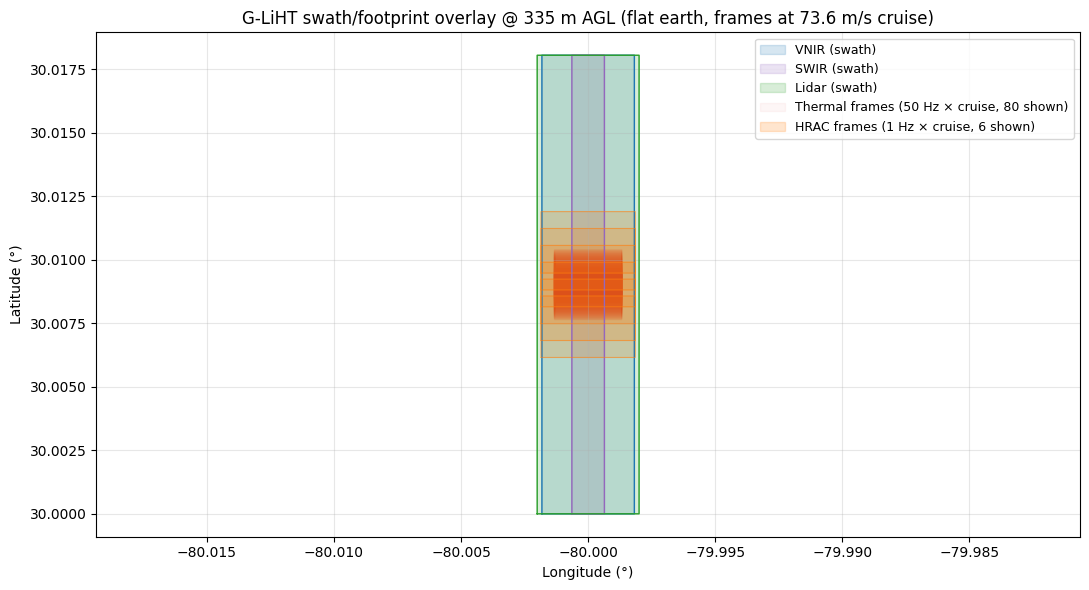

In [3]:
fl = FlightLine.start_length_azimuth(
    lat1=30.0, lon1=-80.0,
    length=2.0 * ureg.kilometer, az=0.0,         # north
    altitude_msl=ALT_NOMINAL,
    site_name='demo_n',
)

# Continuous-swath sensors (pushbrooms + lidar rig).  Use terrain_aware=False
# so the synthetic demo doesn't fetch / depend on DEM data.
swaths = {
    'VNIR (swath)':  (generate_swath_polygon(fl, vnir,      terrain_aware=False), 'C0'),
    'SWIR (swath)':  (generate_swath_polygon(fl, swir,      terrain_aware=False), 'C4'),
    'Lidar (swath)': (generate_swath_polygon(fl, lidar_rig, terrain_aware=False), 'C2'),
}

# Frame-camera footprints at the operational trigger spacing.  Use
# FrameCamera.footprint_polygon_at to avoid hand-rolling lat/lon
# offsets in the notebook.
import pymap3d.vincenty as _v

from hyplan.geometry import wrap_to_180


def _frames_along_line(camera, n_frames, start_d_m, speed_mps):
    """Consecutive frame polygons at operational trigger spacing."""
    period_s = 1.0 / float(camera.frame_rate.m_as('hertz'))
    spacing_m = speed_mps * period_s
    polys = []
    for k in range(n_frames):
        d_m = start_d_m + k * spacing_m
        lat_c, lon_c = _v.vreckon(fl.lat1, fl.lon1, d_m, 0.0)
        lon_c = float(wrap_to_180(lon_c))
        polys.append(camera.footprint_polygon_at(
            float(lat_c), lon_c, ALT_NOMINAL, heading=0.0,
        ))
    return polys


cruise_mps = CRUISE_MPS
line_mid_m = float(fl.length.m_as('meter')) / 2.0

# HRAC: 6 frames spanning ~370 m centred on midpoint (1 Hz × cruise → 74 m apart).
hrac_period_m = cruise_mps / float(hrac.frame_rate.m_as('hertz'))
hrac_polys = _frames_along_line(
    hrac, n_frames=6, start_d_m=line_mid_m - 2.5 * hrac_period_m, speed_mps=cruise_mps,
)
# Thermal: 80 frames spanning ~120 m at 50 Hz × cruise (1.47 m apart — visually a strip).
thermal_period_m = cruise_mps / float(thermal.frame_rate.m_as('hertz'))
thermal_polys = _frames_along_line(
    thermal, n_frames=80, start_d_m=line_mid_m - 40 * thermal_period_m, speed_mps=cruise_mps,
)

fig, ax = plt.subplots(figsize=(11, 6))
for label, (poly, color) in swaths.items():
    xs, ys = poly.exterior.xy
    ax.fill(list(xs), list(ys), color=color, alpha=0.18, label=label)
    ax.plot(list(xs), list(ys), color=color, lw=1.0)

# Thermal: many low-alpha frames; their overlap accumulates to a solid strip.
for i, poly in enumerate(thermal_polys):
    xs, ys = poly.exterior.xy
    ax.fill(list(xs), list(ys), color='C3', alpha=0.04,
            label=f'Thermal frames (50 Hz × cruise, {len(thermal_polys)} shown)' if i == 0 else None)

# HRAC: 6 frames at modest alpha so the overlap regions show as darker bands.
for i, poly in enumerate(hrac_polys):
    xs, ys = poly.exterior.xy
    ax.fill(list(xs), list(ys), color='C1', alpha=0.20,
            label=f'HRAC frames (1 Hz × cruise, {len(hrac_polys)} shown)' if i == 0 else None)
    ax.plot(list(xs), list(ys), color='C1', lw=0.6, alpha=0.6)

# Live readout of widths / footprints / overlap fractions.
for label, sensor in [('VNIR (swath)', vnir), ('SWIR (swath)', swir),
                      ('Lidar rig (swath)', lidar_rig)]:
    w = float(sensor.swath_width(ALT_NOMINAL).m_as('meter'))
    print(f'  {label}: cross-track width @ {ALT_NOMINAL:~} = {w:.0f} m')
for label, cam in [('Thermal (Gobi-640)', thermal), ('HRAC (Phase One)', hrac)]:
    fp = cam.footprint_at(ALT_NOMINAL)
    fp_h = float(fp['height'].m_as('meter'))
    period_s = 1.0 / float(cam.frame_rate.m_as('hertz'))
    spacing = cruise_mps * period_s
    overlap_pct = max(0.0, 1.0 - spacing / fp_h) * 100.0
    print(f'  {label}: footprint {fp["width"]:~.0f} × {fp["height"]:~.0f}, '
          f'frame spacing at cruise = {spacing:.2f} m, '
          f'forward overlap = {overlap_pct:.1f}%')

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_aspect('equal', adjustable='datalim')
ax.set_title(f'G-LiHT swath/footprint overlay @ {ALT_NOMINAL:~} AGL '
             f'(flat earth, frames at {cruise_mps:.1f} m/s cruise)')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
_show(fig)

## 3. Cross-track ground width vs altitude

Sweep AGL from 100 m to 1500 m.  Pushbroom sensors (VNIR + lidar rig)
plot swath width; the frame cameras (thermal Gobi-640 + HRAC) plot
the cross-track footprint width per frame.

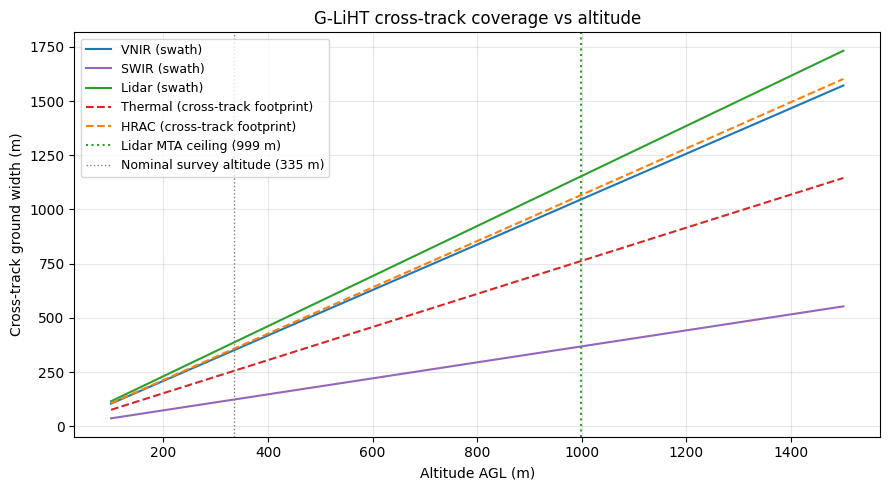

In [4]:
alts_m = np.linspace(100, 1500, 60)
fig, ax = plt.subplots(figsize=(9, 5))
for label, sensor, color in [('VNIR (swath)', vnir, 'C0'),
                              ('SWIR (swath)', swir, 'C4'),
                              ('Lidar (swath)', lidar_rig, 'C2')]:
    widths = [float(sensor.swath_width(a * ureg.meter).m_as('meter')) for a in alts_m]
    ax.plot(alts_m, widths, label=label, color=color)

for label, cam, color in [('Thermal (cross-track footprint)', thermal, 'C3'),
                           ('HRAC (cross-track footprint)', hrac, 'C1')]:
    widths = [
        float(cam.footprint_at(a * ureg.meter)['width'].m_as('meter'))
        for a in alts_m
    ]
    ax.plot(alts_m, widths, label=label, color=color, linestyle='--')

mta_m = float(lidar_unit.mta_practical_max_altitude().m_as('meter'))
ax.axvline(mta_m, color='C2', linestyle=':', lw=1.5,
           label=f'Lidar MTA ceiling ({mta_m:.0f} m)')
ax.axvline(float(ALT_NOMINAL.m_as('meter')), color='gray', linestyle=':', lw=1.0,
           label=f'Nominal survey altitude ({float(ALT_NOMINAL.m_as("meter")):.0f} m)')

ax.set_xlabel('Altitude AGL (m)')
ax.set_ylabel('Cross-track ground width (m)')
ax.set_title('G-LiHT cross-track coverage vs altitude')
ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=9)
fig.tight_layout()
_show(fig)

## 4. Max ground speed vs altitude

Each instrument's binding speed at each altitude.  **The constraint
models are different per instrument** — they're not directly
comparable side-by-side; pick the lower of each instrument's
constraints when the operating point matters:

| Instrument | Constraint model | What it measures |
| --- | --- | --- |
| VNIR / SWIR (pushbroom) | Sub-meter along-track (`ground_speed × frame_period ≤ 1 m`) | Operationally useful ground pixel (see §5 for cross-track ceiling) |
| HRAC / Thermal (frame, geometric) | Forward overlap × frame rate | Adjacent frames cover the required fraction of shared ground |
| HRAC / Thermal (frame, motion blur) | `integration_time × ground_speed` | Ground motion during a single exposure stays under N along-track GSDs |
| Lidar (dual VQ-480i) | Target point density | Ground point density at the requested pts/m² |

Motion-blur integration times: **HRAC** uses the AK 2022 SW66
campaign-documented mechanical shutter speed (1/1000 s).  **Gobi-640
thermal** uses the full 50 Hz frame period (20 ms) as a conservative
proxy — the campaign metadata documents the frame rate but not the
exposure time, and uncooled microbolometers integrate continuously
between readouts, so the actual integration is at most one frame
period.  For 1-pixel along-track blur (`max_blur_pixels=1.0`), both
frame cameras hit their motion-blur limit well below the survey
envelope — confirming that motion blur, not geometric overlap, is
the real binding constraint for the frame cameras at G-LiHT cruise.

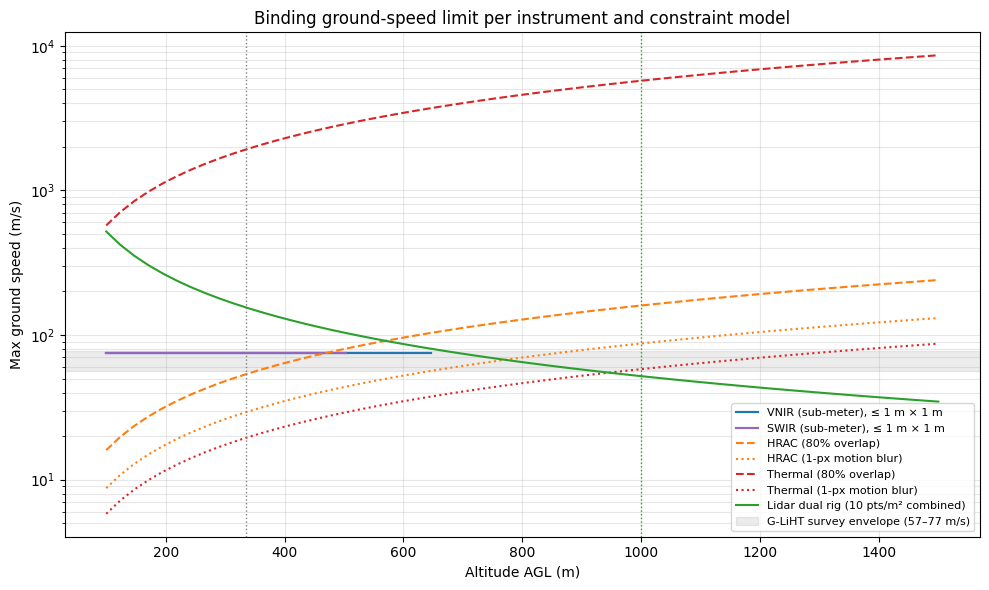

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

# VNIR / SWIR sub-meter speed: flat (altitude-independent), truncated at
# each sensor's cross-track altitude ceiling (where cross-track exceeds 1 m).
def _submeter_speed_curve(sensor, alts_m_arr, target_m=1.0):
    per_px_deg = float(sensor.fov) / sensor.across_track_pixels
    speed = target_m * float(sensor.frame_rate.m_as('hertz'))
    cross_track = np.array([
        a * np.tan(np.radians(per_px_deg)) for a in alts_m_arr
    ])
    speeds = np.full_like(alts_m_arr, speed, dtype=float)
    speeds[cross_track > target_m] = np.nan
    return speeds

for label, sensor, color in [('VNIR (sub-meter)', vnir, 'C0'),
                              ('SWIR (sub-meter)', swir, 'C4')]:
    ax.plot(alts_m, _submeter_speed_curve(sensor, alts_m),
            label=f'{label}, ≤ 1 m × 1 m', color=color, linewidth=1.6)

# Frame cameras: geometric overlap-limited (dashed) vs motion-blur-limited (dotted).
for label, cam, color, overlap_pct in [
    ('HRAC',     hrac,     'C1', HRAC_OVERLAP_PCT),
    ('Thermal',  thermal,  'C3', THERMAL_OVERLAP_PCT),
]:
    overlap_speeds = [
        float(cam.max_ground_speed_for_overlap(a * ureg.meter,
                                               overlap_pct=overlap_pct)
              .m_as('meter / second'))
        for a in alts_m
    ]
    ax.plot(alts_m, overlap_speeds,
            label=f'{label} ({overlap_pct:.0f}% overlap)',
            color=color, linestyle='--')
    blur_speeds = [
        float(cam.max_ground_speed_for_motion_blur(a * ureg.meter,
                                                   max_blur_pixels=1.0)
              .m_as('meter / second'))
        for a in alts_m
    ]
    ax.plot(alts_m, blur_speeds,
            label=f'{label} (1-px motion blur)',
            color=color, linestyle=':')

# Lidar density-limited — uses the dual-rig combined density (both
# VQ-480i units contribute pulses to the same ground swath).
lidar_speeds = []
for a in alts_m:
    try:
        v = lidar_rig.solve_for_groundspeed(
            LIDAR_TARGET_DENSITY, a * ureg.meter, strict_contiguity=False,
        )
        lidar_speeds.append(float(v.m_as('meter / second')))
    except Exception:
        lidar_speeds.append(np.nan)
ax.plot(alts_m, lidar_speeds, label='Lidar dual rig (10 pts/m² combined)', color='C2')

ax.axhspan(SURVEY_LO, SURVEY_HI, color='gray', alpha=0.15,
           label=f'G-LiHT survey envelope ({SURVEY_LO:.0f}–{SURVEY_HI:.0f} m/s)')
ax.axvline(mta_m, color='C2', linestyle=':', lw=1.0)
ax.axvline(float(ALT_NOMINAL.m_as('meter')), color='gray', linestyle=':', lw=1.0)

ax.set_xlabel('Altitude AGL (m)')
ax.set_ylabel('Max ground speed (m/s)')
ax.set_yscale('log')
ax.set_title('Binding ground-speed limit per instrument and constraint model')
ax.grid(alpha=0.3, which='both')
ax.legend(loc='best', fontsize=8)
fig.tight_layout()
_show(fig)

## 5. Pushbroom ground pixel — sub-meter target (VNIR + SWIR)

Both pushbrooms have **integration time = frame period = 13.3 ms**
(AK 2022 SW66 metadata): each row integrates over a full frame's
worth of along-track motion.  The cross-track pixel size is fixed
by sensor optics and altitude; the along-track pixel size is just
`ground_speed × frame_period`.  Each rectangular ground pixel is
integrated coherently — *anisotropic GSD*, not a separate unmodelled
blur term: the elongated dimension *is* the along-track pixel
support.

Strict square-pixel (1× Nyquist) planning gives a needlessly tight
speed limit (~38 m/s VNIR, ~48 m/s SWIR at 335 m AGL — both
*below* the 110–150 kt survey envelope) and isn't what science
products usually require.  A more operationally useful target is
**ground pixels ≤ 1 m in *either* direction** — fine enough for
canopy-scale work, coarse enough to fly inside the envelope.

That target splits cleanly into two independent constraints:

- **Along-track ≤ 1 m**: `ground_speed ≤ 1 m / frame_period` →
  **75 m/s for both pushbrooms** (same 75 Hz frame rate), independent
  of altitude.  Comfortably at the top of the survey envelope.
- **Cross-track ≤ 1 m**: `altitude × tan(FOV / pixels) ≤ 1 m` →
  altitude ceiling depending on each sensor's per-pixel angular
  size.  VNIR's narrower per-pixel angle (0.086°) gives a higher
  ceiling than SWIR's (0.109°).

SWIR is the binding cross-track constraint.  At G-LiHT's nominal
335 m AGL, both pushbrooms sit comfortably inside both limits.

Sub-meter target: ground pixel ≤ 1.0 m in either direction

Along-track speed limit (1 / frame_rate × target):
  VNIR @ 75 Hz:  75.0 m/s (146 kt)
  SWIR @ 75 Hz:  75.0 m/s (146 kt)

Cross-track altitude ceiling (target / tan(FOV / pixels)):
  VNIR (per-pixel 0.0857°):   668 m AGL
  SWIR (per-pixel 0.1089°):   526 m AGL  ← binding

Ground pixels at 335 m (well below either ceiling):
  VNIR at sub-meter limit (75 m/s): cross=50 cm, along=100 cm, aspect=1.99:1
  SWIR at sub-meter limit (75 m/s): cross=64 cm, along=100 cm, aspect=1.57:1


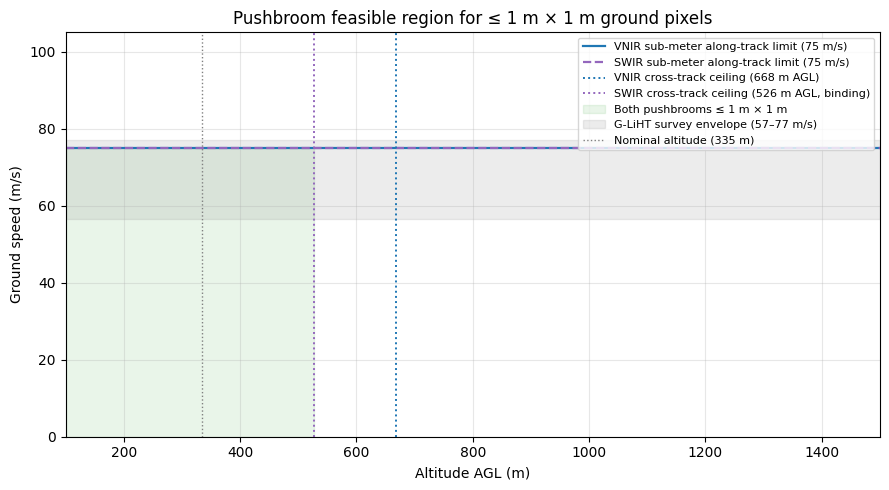

In [6]:
PIXEL_TARGET_M = 1.0

# Sub-meter speed limit (along-track ≤ target): independent of altitude
# because along-track = ground_speed × frame_period.
def submeter_speed(sensor, target_m=PIXEL_TARGET_M):
    return target_m * float(sensor.frame_rate.m_as('hertz'))

# Sub-meter altitude ceiling (cross-track ≤ target): independent of speed
# because cross-track = altitude × tan(FOV / pixels).
def submeter_altitude_ceiling(sensor, target_m=PIXEL_TARGET_M):
    per_px_deg = float(sensor.fov) / sensor.across_track_pixels
    return target_m / np.tan(np.radians(per_px_deg))

vnir_speed = submeter_speed(vnir)
swir_speed = submeter_speed(swir)
vnir_alt_ceiling = submeter_altitude_ceiling(vnir)
swir_alt_ceiling = submeter_altitude_ceiling(swir)


def _kt(speed_mps):
    return (speed_mps * ureg('meter / second')).to('knot').magnitude


print(f'Sub-meter target: ground pixel ≤ {PIXEL_TARGET_M:.1f} m in either direction\n')
print('Along-track speed limit (1 / frame_rate × target):')
print(f'  VNIR @ {float(vnir.frame_rate.m_as("hertz")):.0f} Hz: '
      f'{vnir_speed:5.1f} m/s ({_kt(vnir_speed):.0f} kt)')
print(f'  SWIR @ {float(swir.frame_rate.m_as("hertz")):.0f} Hz: '
      f'{swir_speed:5.1f} m/s ({_kt(swir_speed):.0f} kt)')
print('\nCross-track altitude ceiling (target / tan(FOV / pixels)):')
print(f'  VNIR (per-pixel {float(vnir.fov)/vnir.across_track_pixels:.4f}°): '
      f'{vnir_alt_ceiling:5.0f} m AGL')
print(f'  SWIR (per-pixel {float(swir.fov)/swir.across_track_pixels:.4f}°): '
      f'{swir_alt_ceiling:5.0f} m AGL  ← binding')

print(f'\nGround pixels at {ALT_NOMINAL:~} (well below either ceiling):')
for name, sensor, speed in [('VNIR', vnir, vnir_speed),
                             ('SWIR', swir, swir_speed)]:
    d = sensor.ground_pixel_dimensions(
        ALT_NOMINAL, speed * ureg.meter / ureg.second,
    )
    print(f'  {name} at sub-meter limit ({speed:.0f} m/s): '
          f'cross={d["cross_track"].m_as("centimeter"):.0f} cm, '
          f'along={d["along_track"].m_as("centimeter"):.0f} cm, '
          f'aspect={d["aspect_ratio"]:.2f}:1')

# Plot the feasible region: speed ≤ sub-meter along-track limit,
# altitude ≤ sub-meter cross-track ceiling.  Survey envelope overlaid.
fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(vnir_speed, color='C0', linestyle='-',  lw=1.6,
           label=f'VNIR sub-meter along-track limit ({vnir_speed:.0f} m/s)')
ax.axhline(swir_speed, color='C4', linestyle='--', lw=1.6,
           label=f'SWIR sub-meter along-track limit ({swir_speed:.0f} m/s)')
# VNIR + SWIR coincide at 75 m/s — same frame rate; the SWIR line draws on top.

ax.axvline(vnir_alt_ceiling, color='C0', linestyle=':', lw=1.4,
           label=f'VNIR cross-track ceiling ({vnir_alt_ceiling:.0f} m AGL)')
ax.axvline(swir_alt_ceiling, color='C4', linestyle=':', lw=1.4,
           label=f'SWIR cross-track ceiling ({swir_alt_ceiling:.0f} m AGL, binding)')

# Feasible region for the binding (SWIR) sensor.
ax.fill_betweenx(
    [0, min(vnir_speed, swir_speed)],
    alts_m[0], swir_alt_ceiling,
    color='C2', alpha=0.10, label='Both pushbrooms ≤ 1 m × 1 m',
)

ax.axhspan(SURVEY_LO, SURVEY_HI, color='gray', alpha=0.15,
           label=f'G-LiHT survey envelope ({SURVEY_LO:.0f}–{SURVEY_HI:.0f} m/s)')
ax.axvline(float(ALT_NOMINAL.m_as('meter')), color='gray', linestyle=':',
           lw=1.0, label=f'Nominal altitude ({float(ALT_NOMINAL.m_as("meter")):.0f} m)')

ax.set_xlim(alts_m[0], alts_m[-1])
ax.set_ylim(0, max(vnir_speed, swir_speed) * 1.4)
ax.set_xlabel('Altitude AGL (m)')
ax.set_ylabel('Ground speed (m/s)')
ax.set_title(f'Pushbroom feasible region for ≤ {PIXEL_TARGET_M:.0f} m × {PIXEL_TARGET_M:.0f} m ground pixels')
ax.grid(alpha=0.3)
ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()
_show(fig)

## 6. Altitude ceiling — which instrument caps the maximum?

Only the lidar has a hard ceiling.  At the configured VQ-480i PRF the
**maximum-time-of-flight ambiguity (MTA)** limit binds before the
radiometric range limit.  Doubling the PRF would halve the unambiguous
range and tighten the ceiling — relevant if you're tempted to bump
PRF for denser returns.

In [7]:
print(f'Lidar MTA practical max altitude: '
      f'{lidar_unit.mta_practical_max_altitude():~.0f}')
print(f'Lidar unambiguous range (theoretical):    '
      f'{lidar_unit.mta_max_unambiguous_range():~.0f}')
print(f'Lidar radiometric max range:              '
      f'{lidar_unit.max_range:~.0f}')
print()
print('HRAC has no hard altitude ceiling — GSD scales linearly:')
for a in (500, 1000, 1500):
    gsd = hrac.ground_sample_distance(a * ureg.meter)['x']
    print(f'  altitude {a:>4} m  →  HRAC GSD_x = {gsd.m_as("centimeter"):.1f} cm')

Lidar MTA practical max altitude: 999 m
Lidar unambiguous range (theoretical):    999 m
Lidar radiometric max range:              1850 m

HRAC has no hard altitude ceiling — GSD scales linearly:
  altitude  500 m  →  HRAC GSD_x = 4.2 cm
  altitude 1000 m  →  HRAC GSD_x = 8.5 cm
  altitude 1500 m  →  HRAC GSD_x = 12.7 cm


## 7. Operating-point summary at 335 m AGL

All values live from the reference instances at the nominal G-LiHT
altitude.

In [8]:
def _ms(value_quantity):
    return float(value_quantity.m_as('meter / second'))

rows = [
    ('Max altitude (AGL)',
     f'{float(lidar_unit.mta_practical_max_altitude().m_as("meter")):.0f} m',
     'Lidar MTA range', 'Lidar'),
    ('Cruise speed @ 335 m AGL (KingAirA90)',
     f'{CRUISE_MPS:.1f} m/s ({float(aircraft.cruise_speed_at(ALT_NOMINAL).m_as("knot")):.0f} kt)',
     'Aircraft calibrated TAS', 'Aircraft'),
    ('VNIR sub-meter speed (along-track ≤ 1 m)',
     f'{vnir_speed:.1f} m/s',
     'ground_speed × frame_period ≤ 1 m', 'VNIR'),
    ('SWIR sub-meter speed (along-track ≤ 1 m)',
     f'{swir_speed:.1f} m/s',
     'ground_speed × frame_period ≤ 1 m', 'SWIR'),
    ('VNIR sub-meter altitude ceiling (cross-track ≤ 1 m)',
     f'{vnir_alt_ceiling:.0f} m AGL',
     'altitude × tan(FOV/pixels) ≤ 1 m', 'VNIR'),
    ('SWIR sub-meter altitude ceiling (cross-track ≤ 1 m)',
     f'{swir_alt_ceiling:.0f} m AGL',
     'altitude × tan(FOV/pixels) ≤ 1 m', 'SWIR (binding)'),
    ('HRAC max speed @ 335 m, 80% overlap',
     f'{_ms(hrac.max_ground_speed_for_overlap(ALT_NOMINAL, overlap_pct=HRAC_OVERLAP_PCT)):.1f} m/s',
     '80% forward overlap', 'HRAC'),
    ('HRAC max speed @ 335 m, 1-pixel blur',
     f'{_ms(hrac.max_ground_speed_for_motion_blur(ALT_NOMINAL, max_blur_pixels=1.0)):.1f} m/s',
     'integration × speed ≤ 1 GSD', 'HRAC (binding)'),
    ('Thermal max speed @ 335 m, 80% overlap (geometric)',
     f'{_ms(thermal.max_ground_speed_for_overlap(ALT_NOMINAL, overlap_pct=THERMAL_OVERLAP_PCT)):.0f} m/s',
     '80% forward overlap (not binding)', 'Thermal'),
    ('Thermal max speed @ 335 m, 1-pixel blur',
     f'{_ms(thermal.max_ground_speed_for_motion_blur(ALT_NOMINAL, max_blur_pixels=1.0)):.1f} m/s',
     'integration × speed ≤ 1 GSD', 'Thermal (binding)'),
    ('Lidar rig max speed @ 335 m, 10 pts/m² combined',
     f'{_ms(lidar_rig.solve_for_groundspeed(LIDAR_TARGET_DENSITY, ALT_NOMINAL, strict_contiguity=False)):.1f} m/s',
     'Combined target point density (dual-rig)', 'Lidar rig'),
    ('Widest cross-track @ 335 m',
     f'{float(lidar_rig.swath_width(ALT_NOMINAL).m_as("meter")):.0f} m',
     'Swath width', 'Lidar rig'),
    ('Narrowest cross-track @ 335 m',
     f'{float(swir.swath_width(ALT_NOMINAL).m_as("meter")):.0f} m',
     'Swath width', 'SWIR'),
]
pd.DataFrame(rows, columns=['Constraint', 'Value', 'Constraint model', 'Set by'])

,Constraint,Value,Constraint model,Set by
0,Max altitude (AGL),999 m,Lidar MTA range,Lidar
1,Cruise speed @ 335 m AGL (KingAirA90),73.6 m/s (143 kt),Aircraft calibrated TAS,Aircraft
2,VNIR sub-meter speed (along-track ≤ 1 m),75.0 m/s,ground_speed × frame_period ≤ 1 m,VNIR
3,SWIR sub-meter speed (along-track ≤ 1 m),75.0 m/s,ground_speed × frame_period ≤ 1 m,SWIR
4,VNIR sub-meter altitude ceiling (cross-track ≤...,668 m AGL,altitude × tan(FOV/pixels) ≤ 1 m,VNIR
5,SWIR sub-meter altitude ceiling (cross-track ≤...,526 m AGL,altitude × tan(FOV/pixels) ≤ 1 m,SWIR (binding)
6,"HRAC max speed @ 335 m, 80% overlap",53.6 m/s,80% forward overlap,HRAC
7,"HRAC max speed @ 335 m, 1-pixel blur",29.3 m/s,integration × speed ≤ 1 GSD,HRAC (binding)
8,"Thermal max speed @ 335 m, 80% overlap (geomet...",1918 m/s,80% forward overlap (not binding),Thermal
9,"Thermal max speed @ 335 m, 1-pixel blur",19.5 m/s,integration × speed ≤ 1 GSD,Thermal (binding)


## 8. What this means for mission design

Ranked binding speeds at 335 m AGL, by constraint model:

```
Thermal motion blur (1 px):  ~20 m/s     ← binds frame-camera operations
HRAC motion blur (1 px):     ~29 m/s     ← binds frame-camera operations
HRAC 80% overlap (geom):     ~54 m/s     ← rarely the limit at G-LiHT cruise
G-LiHT survey envelope:      57–77 m/s   ← what the platform actually flies
VNIR/SWIR sub-meter speed:   ~75 m/s     ← along-track ≤ 1 m at 75 Hz
Lidar rig 10 pts/m² combined: ~155 m/s   ← comfortably above the envelope
Thermal 80% overlap (geom):  ~1.9 km/s   ← geometric ceiling is uninformative
Max altitude (Lidar MTA):    ~999 m AGL
```

Sub-meter altitude ceilings (cross-track ≤ 1 m):

```
SWIR cross-track ceiling:     ~526 m AGL  ← binding pushbroom altitude
VNIR cross-track ceiling:     ~668 m AGL
Lidar MTA practical ceiling:  ~999 m AGL  ← binding altitude overall
```

Per-instrument takeaways:

- **VNIR / SWIR — sub-meter pushbroom planning is comfortable inside
  the envelope.**  Targeting ≤ 1 m × 1 m ground pixels (rather than
  enforcing strictly square Nyquist pixels) puts the along-track
  speed limit at ~75 m/s for both — at the top of the 110–150 kt
  survey envelope — and gives altitude ceilings of ~526 m (SWIR,
  binding) and ~668 m (VNIR).  At G-LiHT's nominal 335 m AGL, both
  pushbrooms deliver sub-meter in both directions at the full 75 m/s
  cruise (53 × 100 cm VNIR, 65 × 100 cm SWIR — anisotropic at ~1.5–
  2:1, but both dimensions inside the sub-meter target).  Strict
  square pixels at 335 m would have demanded slowing to 38–48 m/s,
  *below* the survey envelope.
- **HRAC — motion blur (not overlap) is binding.** The 80% overlap
  geometric limit (~54 m/s) suggests HRAC could just keep up with
  the survey floor, but the 1/1000 s shutter sees 2.5 pixels of
  along-track blur at cruise.  Operators tolerate this in practice
  (HRAC is a context imager, not a metric product), but tight
  photogrammetry would require slowing or accepting the smear.
- **Thermal — motion blur dominates.** Each Gobi-640 exposure has
  ~3.8 pixels of along-track blur at cruise (using the 20 ms frame
  period as a conservative proxy for the undocumented integration
  time).  The geometric overlap limit (~2 km/s) is uninformative;
  the motion-blur model gives ~20 m/s for 1-pixel blur, far below
  the envelope.  And — answer to a common reasonable intuition —
  the 99% frame overlap does **not** compensate for motion blur in
  the way it might seem.  Every overlapping frame carries the
  *same* along-track integration smear (the platform moves the
  same 1.48 m during each 20 ms exposure), so registering and
  stacking frames recovers SNR via averaging but **not spatial
  resolution**.  Multi-frame deconvolution can recover some
  sharpness with priors, but the motion-blur OTF has hard zeros
  that frames with identical kernels cannot fill.  Real recovery
  would need shorter integration, optical stabilization, or a TDI
  sensor architecture — none of which the Gobi-640 has.
- **Lidar — altitude is the bottleneck, not speed.**  At 335 m AGL
  the dual VQ-480i's combined 10 pts/m² speed is ~155 m/s — well
  above the survey envelope, so density is genuinely comfortable
  here.  (Each unit alone would manage ~78 m/s; pitching two units
  forward and backward at the same swath doubles the combined
  density and halves the density-limited speed-per-unit-density.)
  As altitude rises the rig's density-limited speed drops with
  swath_width — by the 999 m MTA ceiling it's ~52 m/s, still in the
  envelope; the altitude ceiling (not density) is the binding
  constraint.
- **Cross-track planning** is driven by whichever sensor must be
  covered.  Operational 30% overlap matches ~87 m line spacing
  against the 124 m SWIR swath; the wider sensors (lidar 387 m,
  HRAC 358 m, VNIR 351 m, thermal frame 256 m) all over-collect at
  the same pitch.